In [1]:
#add all the libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import seaborn as sns
from sklearn.metrics import r2_score, accuracy_score

In [2]:
#loading the dataset
df=pd.read_csv('Position_Salaries.csv')
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [17]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


In [4]:
df.isnull().sum()

Position    0
Level       0
Salary      0
dtype: int64

In [5]:
#defining independent and dependent variables
X=df.iloc[:, 1:-1].values
y=df.iloc[:, -1].values
print(X)
print(y)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]
[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


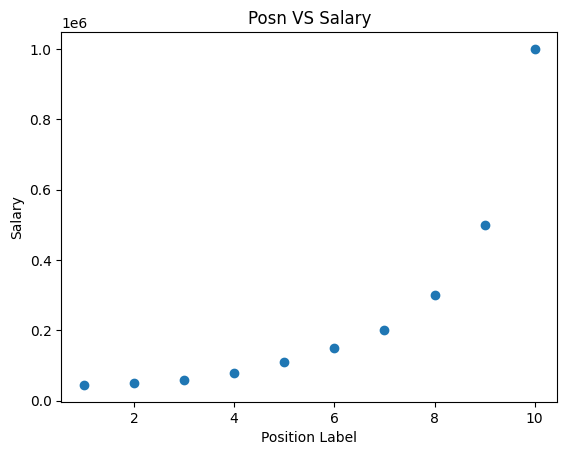

In [6]:
#check linearity
plt.scatter(X,y)
plt.xlabel('Position Label')
plt.ylabel('Salary')
plt.title('Posn VS Salary')
plt.show()

- No splitting data as dataset is very low

In [7]:
# Training the Linear Regression model on the whole dataset
lin_reg=LinearRegression()
lin_reg.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
# Training the Polynomial Regression model on the whole dataset
poly_reg=PolynomialFeatures(degree=4)
X_poly=poly_reg.fit_transform(X)
lin_reg_2=LinearRegression()
lin_reg_2.fit(X_poly, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
#predicting with trained model
y_pred=lin_reg_2.predict(X_poly)
print(y_pred)
print(y)

[ 53356.64335675  31759.90675984  58642.1911421   94632.86713282
 121724.94172495 143275.05827509 184003.49650352 289994.17249417
 528694.63869462 988916.08391612]
[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


In [10]:
#checkin residual value
residual=y_pred-y
print(residual)

[  8356.64335675 -18240.09324016  -1357.8088579   14632.86713282
  11724.94172495  -6724.94172491 -15996.50349648 -10005.82750583
  28694.63869462 -11083.91608388]


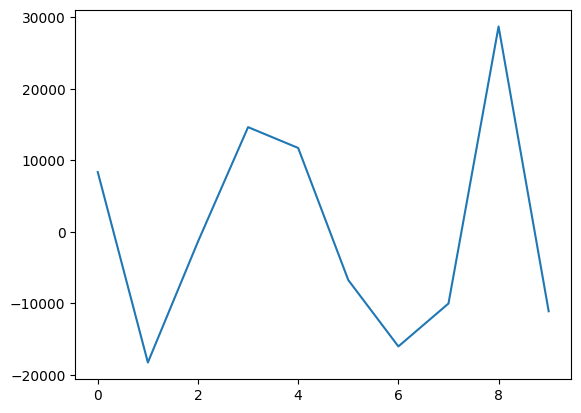

In [11]:
#auto-correlation
plt.plot(residual)

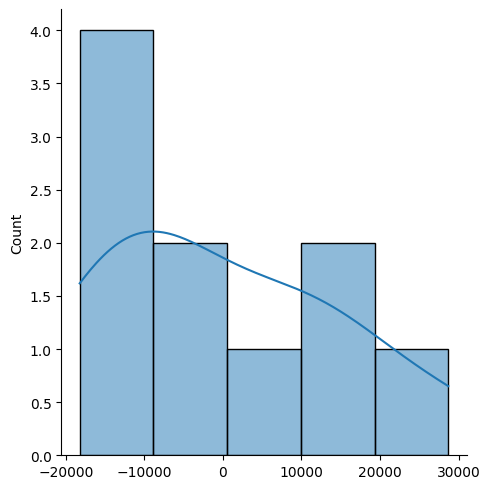

In [12]:
#normal residual
sns.displot(residual, kde=True)

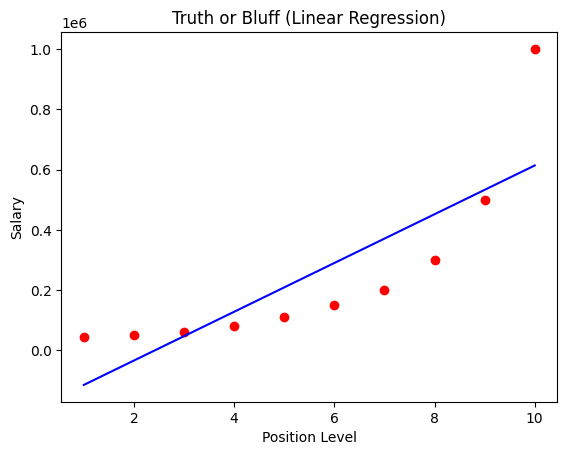

In [13]:
# Visualising the Linear Regression results
plt.scatter(X, y, color = 'red')
plt.plot(X, lin_reg.predict(X), color = 'blue')
plt.title('Truth or Bluff (Linear Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.savefig('lin_reg.png')
plt.show()

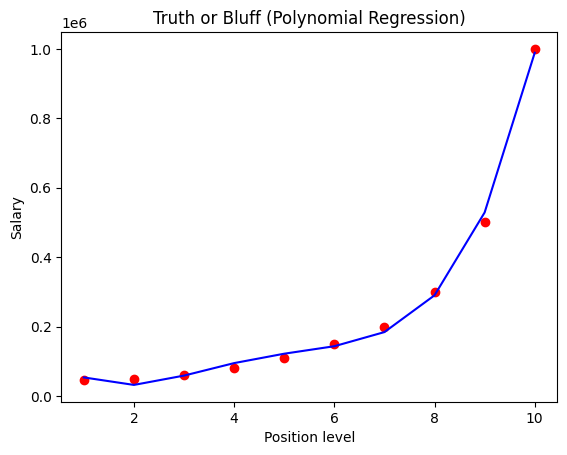

In [14]:
# Visualising the Polynomial Regression results
plt.scatter(X, y, color = 'red')
plt.plot(X, lin_reg_2.predict(poly_reg.fit_transform(X)), color = 'blue')
plt.title('Truth or Bluff (Polynomial Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.savefig('poly_reg.png')
plt.show()

In [15]:
# Predicting a new result with Linear Regression
lin_reg.predict([[6.5]])

array([330378.78787879])

In [16]:
# Predicting a new result with Polynomial Regression
lin_reg_2.predict(poly_reg.fit_transform([[6.5]]))

array([158862.45265155])